# 12 — High-pass filters (`math`, SciPy, PyTorch, python-control)

**Baseline:** the complementary first-order high-pass

$$
H(s) = \frac{\tau s}{\tau s + 1}, \qquad \tau = \frac{1}{2\pi f_c}
$$

A square wave plus a DC offset keeps the edges and dumps the bias. Same four stacks as notebooks `10` / `11`.

| Stack | What it actually computes |
| --- | --- |
| python-control | continuous \(H(s)\), Bode, `forced_response` |
| `math` | first-order high-pass IIR |
| SciPy | bilinear `butter` high-pass + `lfilter` |
| PyTorch | the IIR on `cuda`, then a `conv1d` FIR (identity − low-pass) |

In [1]:
from __future__ import annotations

import math
import time

import control as ct
import matplotlib.pyplot as plt
import numpy as np
import torch
from scipy import signal

%matplotlib inline

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"python-control {ct.__version__}   torch {torch.__version__}   device {device}")
if device.type == "cuda":
    print(f"CUDA {torch.version.cuda}  |  {torch.cuda.get_device_name(0)}")


python-control 0.10.2   torch 2.14.0+cu132   device cuda
CUDA 13.2  |  NVIDIA GeForce RTX 3060


In [2]:
def bode_mag_phase(sys, omega):
    frd = ct.frequency_response(sys, omega=omega)
    if hasattr(frd, "magnitude"):
        w = np.asarray(frd.frequency).reshape(-1)
        m = np.asarray(frd.magnitude).reshape(-1)
        p = np.asarray(frd.phase).reshape(-1)
    else:
        mag, phase, om = frd
        w = np.asarray(om).reshape(-1)
        m = np.asarray(mag).reshape(-1)
        p = np.asarray(phase).reshape(-1)
    return w, m, p


def plot_bode(sys, title, marks=()):
    w, m, p = bode_mag_phase(sys, np.logspace(0, 5, 500))
    fig, axes = plt.subplots(2, 1, figsize=(8, 5), sharex=True)
    axes[0].semilogx(w / (2 * np.pi), 20 * np.log10(np.maximum(m, 1e-16)))
    axes[1].semilogx(w / (2 * np.pi), np.degrees(np.unwrap(p)))
    for f, lab in marks:
        axes[0].axvline(f, color="k", ls="--", lw=1, label=lab)
        axes[1].axvline(f, color="k", ls="--", lw=1)
    axes[0].set_ylabel("mag (dB)")
    axes[1].set_ylabel("phase (deg)")
    axes[1].set_xlabel("frequency (Hz)")
    for ax in axes:
        ax.grid(True, which="both", alpha=0.3)
    if marks:
        axes[0].legend()
    fig.suptitle(title)
    fig.tight_layout()
    plt.show()
    return w, m, p


def max_abs(a, b) -> float:
    return float(np.max(np.abs(np.asarray(a, dtype=np.float64) - np.asarray(b, dtype=np.float64))))


In [3]:
FS_HZ = 8_192
DURATION_S = 0.08
F0_HZ = 220.0
FC_HZ = 80.0
DC = 0.6
N = int(FS_HZ * DURATION_S)
DT = 1.0 / FS_HZ
TAU = 1.0 / (2.0 * math.pi * FC_HZ)

t = np.arange(N, dtype=np.float64) / FS_HZ
u = DC + signal.square(2.0 * np.pi * F0_HZ * t)
print(f"tau = {TAU*1e3:.3f} ms   fc = {FC_HZ} Hz   f0 = {F0_HZ} Hz   device = {device}")

tau = 1.989 ms   fc = 80.0 Hz   f0 = 220.0 Hz   device = cuda


## python-control — \(H(s)\), Bode, forced response

<TransferFunction>: sys[0]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

    0.001989 s
  --------------
  0.001989 s + 1


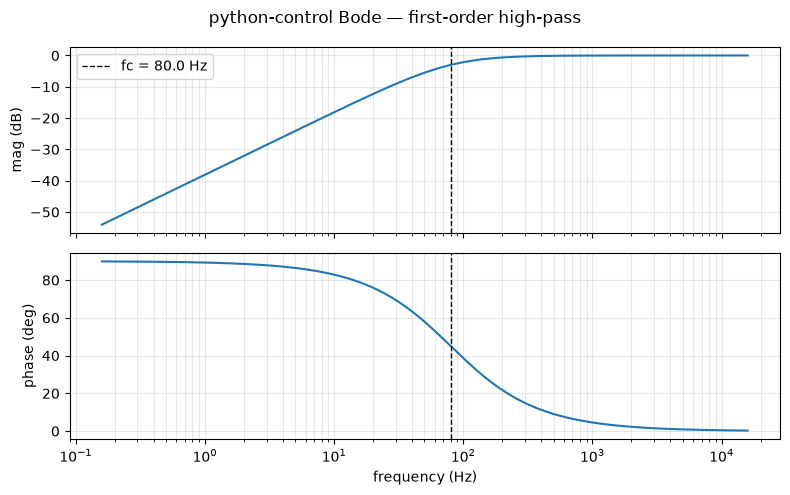

(array([1.00000000e+00, 1.02334021e+00, 1.04722519e+00, 1.07166765e+00,
        1.09668060e+00, 1.12227736e+00, 1.14847155e+00, 1.17527712e+00,
        1.20270833e+00, 1.23077980e+00, 1.25950646e+00, 1.28890361e+00,
        1.31898690e+00, 1.34977233e+00, 1.38127630e+00, 1.41351558e+00,
        1.44650734e+00, 1.48026913e+00, 1.51481892e+00, 1.55017512e+00,
        1.58635653e+00, 1.62338243e+00, 1.66127252e+00, 1.70004698e+00,
        1.73972643e+00, 1.78033202e+00, 1.82188534e+00, 1.86440853e+00,
        1.90792422e+00, 1.95245558e+00, 1.99802631e+00, 2.04466067e+00,
        2.09238348e+00, 2.14122015e+00, 2.19119669e+00, 2.24233968e+00,
        2.29467637e+00, 2.34823460e+00, 2.40304289e+00, 2.45913043e+00,
        2.51652705e+00, 2.57526333e+00, 2.63537052e+00, 2.69688063e+00,
        2.75982639e+00, 2.82424133e+00, 2.89015972e+00, 2.95761666e+00,
        3.02664806e+00, 3.09729067e+00, 3.16958209e+00, 3.24356081e+00,
        3.31926620e+00, 3.39673858e+00, 3.47601918e+00, 3.557150

In [4]:
sys_hp = ct.tf([TAU, 0.0], [TAU, 1.0])
print(sys_hp)
t_ct, y_ct = ct.forced_response(sys_hp, T=t, U=u)
plot_bode(sys_hp, "python-control Bode — first-order high-pass", marks=[(FC_HZ, f"fc = {FC_HZ} Hz")])

## `math` — complementary Euler IIR

From \(\tau \dot{y} + y = \tau \dot{u}\), or equivalently \(y = u - y_\\mathrm{lp}\) with the same \(\alpha = \Delta t / (\tau + \Delta t)\) as notebook `10`:

$$
y[n] = \alpha\,(y[n-1] + u[n] - u[n-1]), \qquad \alpha = \frac{\tau}{\tau + \Delta t}.
$$

In [5]:
def math_highpass(u_list: list[float], dt: float, tau: float) -> list[float]:
    alpha = tau / (tau + dt)
    y = 0.0
    u_prev = 0.0
    out = []
    for un in u_list:
        y = alpha * (y + un - u_prev)
        u_prev = un
        out.append(y)
    return out


y_math = math_highpass(u.tolist(), DT, TAU)
print(f"alpha = {TAU / (TAU + DT):.6f}   last y = {y_math[-1]:.4f}")

alpha = 0.942188   last y = -1.2406


## SciPy — bilinear Butterworth high-pass (order 1)

In [6]:
b_sp, a_sp = signal.butter(N=1, Wn=FC_HZ, btype="high", fs=FS_HZ, analog=False)
y_sp = signal.lfilter(b_sp, a_sp, u)
print("b =", b_sp)
print("a =", a_sp)

b = [ 0.97022454 -0.97022454]
a = [ 1.         -0.94044908]


## PyTorch — sequential IIR on device + FIR `conv1d`

The FIR is a unit impulse minus the Hamming-sinc low-pass from notebook `10`. `conv1d` is one batched CUDA kernel; the IIR is the readable recurrence.

In [7]:
def torch_highpass_iir(u_t: torch.Tensor, dt: float, tau: float) -> torch.Tensor:
    alpha = tau / (tau + dt)
    y = torch.zeros((), device=u_t.device, dtype=u_t.dtype)
    u_prev = torch.zeros((), device=u_t.device, dtype=u_t.dtype)
    out = torch.empty_like(u_t)
    for i in range(u_t.numel()):
        un = u_t[i]
        y = alpha * (y + un - u_prev)
        u_prev = un
        out[i] = y
    return out


def torch_fir_highpass(u_t: torch.Tensor, fc: float, fs: float, taps: int = 129) -> torch.Tensor:
    n = torch.arange(taps, device=u_t.device, dtype=u_t.dtype) - (taps - 1) / 2
    fc_n = fc / fs
    h_lp = 2 * fc_n * torch.sinc(2 * fc_n * n)
    h_lp = h_lp * torch.hamming_window(taps, periodic=False, device=u_t.device, dtype=u_t.dtype)
    h_lp = h_lp / h_lp.sum()
    mid = torch.zeros_like(h_lp)
    mid[taps // 2] = 1.0
    h = mid - h_lp
    pad = taps // 2
    return torch.nn.functional.conv1d(u_t.view(1, 1, -1), h.view(1, 1, -1), padding=pad).view(-1)


u_th = torch.as_tensor(u, device=device, dtype=torch.float32)
if device.type == "cuda":
    torch.cuda.synchronize()
y_th = torch_highpass_iir(u_th, DT, TAU)
y_fir_th = torch_fir_highpass(u_th, FC_HZ, FS_HZ)
if device.type == "cuda":
    torch.cuda.synchronize()
print("IIR", y_th.device, float(y_th[-1]))
print("FIR", y_fir_th.device, float(y_fir_th[-1]))
y_gpu = y_th.detach().cpu().numpy()
y_fir = y_fir_th.detach().cpu().numpy()

IIR cuda:0 -1.2406363487243652
FIR cuda:0 -0.8399305939674377


## Compare time responses

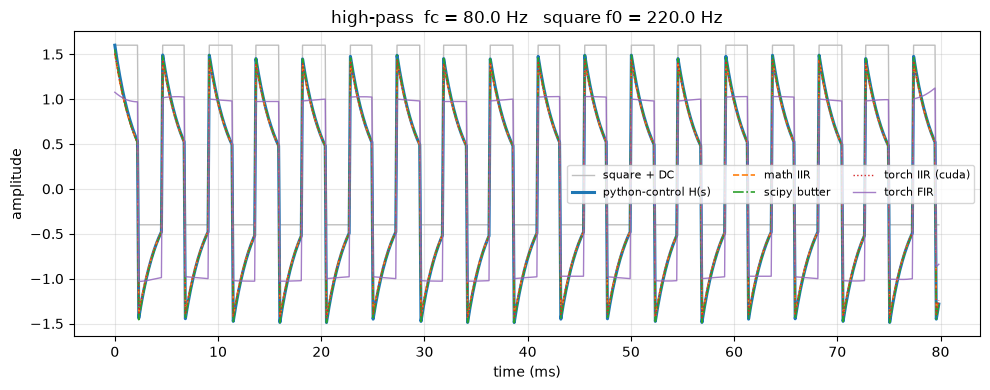

control vs math   9.250e-02
control vs scipy  4.764e-02
math vs torch     6.433e-07
mean(u)=0.623  mean(y_ct)=0.022  (DC should be gone)


In [8]:
ms = t * 1e3
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(ms, u, color="0.75", lw=1.0, label="square + DC")
ax.plot(ms, y_ct, lw=2.2, label="python-control H(s)")
ax.plot(ms, y_math, lw=1.2, ls="--", label="math IIR")
ax.plot(ms, y_sp, lw=1.2, ls="-.", label="scipy butter")
ax.plot(ms, y_gpu, lw=1.0, ls=":", label=f"torch IIR ({device})")
ax.plot(ms, y_fir, lw=1.0, alpha=0.85, label="torch FIR")
ax.set_xlabel("time (ms)")
ax.set_ylabel("amplitude")
ax.set_title(f"high-pass  fc = {FC_HZ} Hz   square f0 = {F0_HZ} Hz")
ax.grid(True, alpha=0.3)
ax.legend(ncol=3, fontsize=8)
fig.tight_layout()
plt.show()

print(f"control vs math   {max_abs(y_ct, y_math):.3e}")
print(f"control vs scipy  {max_abs(y_ct, y_sp):.3e}")
print(f"math vs torch     {max_abs(y_math, y_gpu):.3e}")
print(f"mean(u)={u.mean():.3f}  mean(y_ct)={np.mean(y_ct):.3f}  (DC should be gone)")

## GPU occupancy — IIR loop vs FIR `conv1d`

Longer buffers so kernel time dominates. The sequential IIR cannot fill an RTX-class GPU; FIR can.

In [9]:
N_BENCH = 250_000
u_b = torch.randn(N_BENCH, device=device, dtype=torch.float32)


def bench(fn, warmup=1, reps=3):
    for _ in range(warmup):
        fn()
    if device.type == "cuda":
        torch.cuda.synchronize()
    t0 = time.perf_counter()
    for _ in range(reps):
        fn()
    if device.type == "cuda":
        torch.cuda.synchronize()
    return (time.perf_counter() - t0) / reps


t_iir = bench(lambda: torch_highpass_iir(u_b[:8_192], DT, TAU))
t_fir = bench(lambda: torch_fir_highpass(u_b, FC_HZ, FS_HZ))
print(f"torch IIR  n=8192     {t_iir*1e3:8.2f} ms   device={device}")
print(f"torch FIR  n={N_BENCH}  {t_fir*1e3:8.2f} ms   device={device}")
print("FIR is the GPU-native form; IIR is the readable one.")

torch IIR  n=8192       256.27 ms   device=cuda
torch FIR  n=250000      1.93 ms   device=cuda
FIR is the GPU-native form; IIR is the readable one.


## Takeaways

- High-pass is the complement of notebook `10`: same \(\tau\), numerator \(\tau s\).
- DC in the square wave is rejected on every stack; the 220 Hz edges remain.
- SciPy Butterworth is a different discretization — close, not bit-identical.
- `conv1d` FIR is where the GPU earns its keep. Next: notch / band-stop (`13`).